
Iteration 0
  Misfit J = 1.357225e+01
  Direction: nonlinear CG (PR)
  beta = 0.000000e+00
  g^T p = -2.916421e+01
  Pica epsilon = 2.243242e-02
  Pica alpha   = 9.205049e-01
  Accepted alpha = 9.205049e-01, J_trial = 1.077575e-01, backtracking = 0

Iteration 1
  Misfit J = 1.077575e-01
  Direction: nonlinear CG (PR)
  beta = 1.917957e-02
  g^T p = -1.590564e-01
  Pica epsilon = 3.429569e-01
  Pica alpha   = 1.068184e+00
  Accepted alpha = 1.068184e+00, J_trial = 2.214993e-02, backtracking = 0

Iteration 2
  Misfit J = 2.214993e-02
  Direction: nonlinear CG (PR)
  beta = 1.692597e-02
  g^T p = -1.059986e-02
  Pica epsilon = 1.487775e+00
  Pica alpha   = 1.072096e+00
  Accepted alpha = 1.072096e+00, J_trial = 1.641289e-02, backtracking = 0

Iteration 3
  Misfit J = 1.641289e-02
  Direction: nonlinear CG (PR)
  beta = 9.277474e-02
  g^T p = -9.279269e-04
  Pica epsilon = 4.417224e+00
  Pica alpha   = 1.559225e+00
  Accepted alpha = 1.559225e+00, J_trial = 1.566130e-02, backtracking = 0


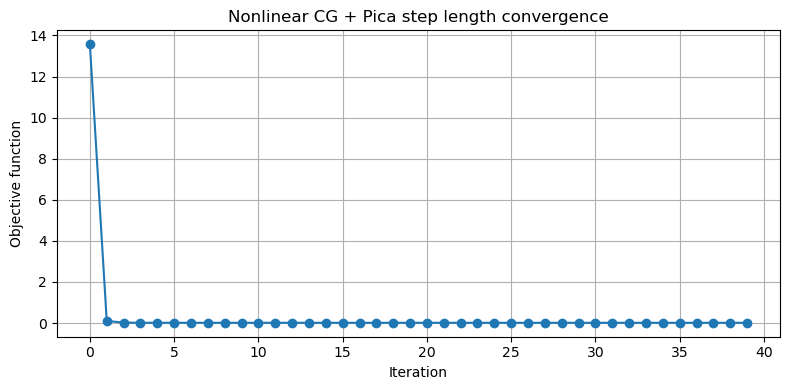

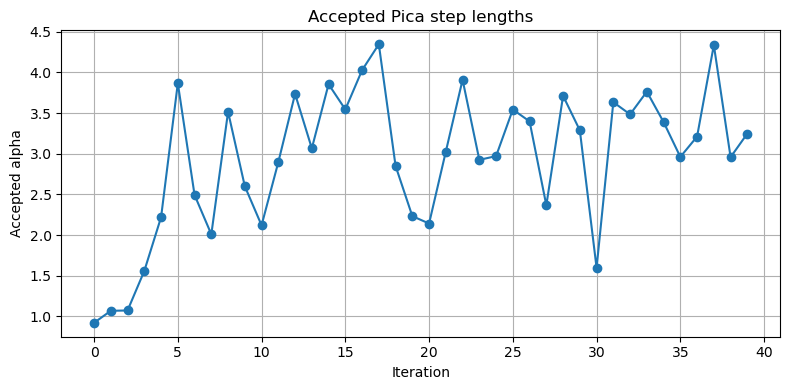

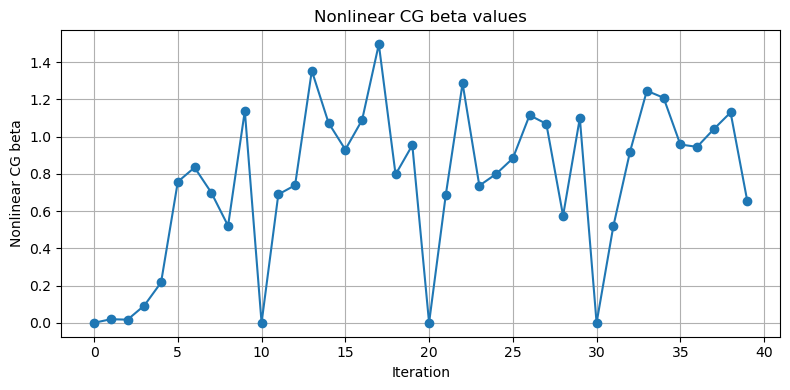

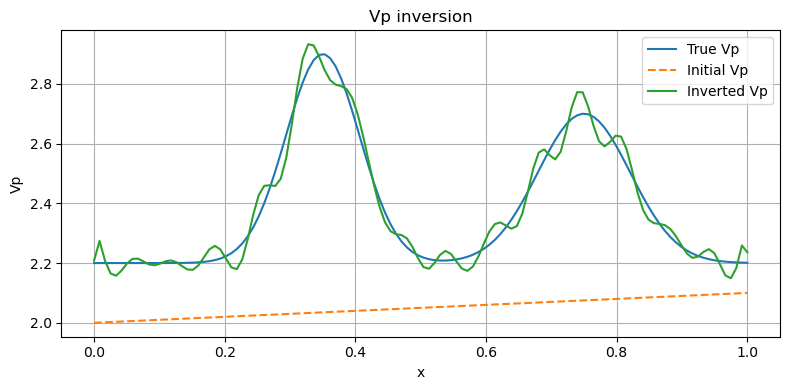

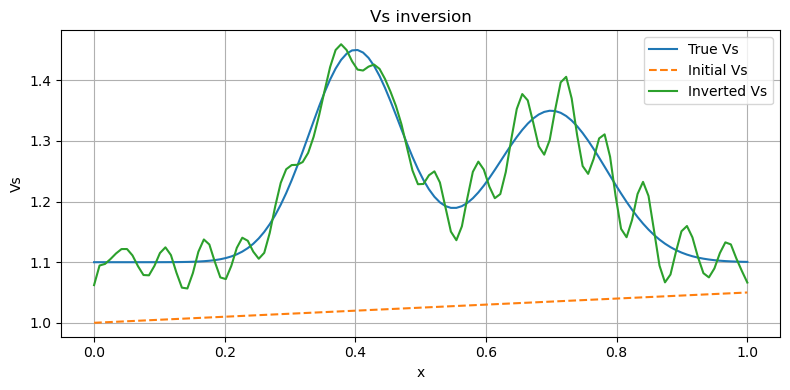

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Utility functions for multiparameter models
# ------------------------------------------------------------

def pack_model(vp, vs):
    """
    Pack multiparameter model into one vector.
    """
    return np.concatenate([vp.ravel(), vs.ravel()])


def unpack_model(m, n):
    """
    Unpack model vector into vp and vs.
    """
    vp = m[:n]
    vs = m[n:]
    return vp, vs


def dot_model(a, b):
    """
    Dot product in model space.
    For real FWI, this could include parameter weights.
    """
    return np.dot(a, b)


def norm_model(a):
    return np.sqrt(dot_model(a, a))


def apply_bounds(m, n, vp_min=1.5, vp_max=5.0, vs_min=0.5, vs_max=3.0):
    """
    Apply simple physical bounds to Vp and Vs.
    Units are arbitrary here.
    """
    vp, vs = unpack_model(m, n)

    vp = np.clip(vp, vp_min, vp_max)
    vs = np.clip(vs, vs_min, vs_max)

    # Optional physical condition: Vp > Vs
    vs = np.minimum(vs, 0.95 * vp)

    return pack_model(vp, vs)


# ------------------------------------------------------------
# 2. Toy nonlinear forward problem
# ------------------------------------------------------------

def build_smoothing_matrix(n, sigma=3.0):
    """
    Build a simple Gaussian-like smoothing matrix.
    This plays the role of wave propagation spreading sensitivity.
    """
    x = np.arange(n)
    A = np.zeros((n, n))

    for i in range(n):
        A[i, :] = np.exp(-0.5 * ((x - i) / sigma) ** 2)

    A /= A.sum(axis=1, keepdims=True)
    return A


def forward_model(m, n, A):
    """
    Toy nonlinear forward model.

    In real FWI, this would be your elastic wave-equation solver:
        d_cal = forward_elastic(vp, vs, rho, geometry)

    Here we make synthetic data sensitive to both Vp and Vs.
    """
    vp, vs = unpack_model(m, n)

    d1 = A @ vp
    d2 = A @ vs

    # Nonlinear coupling term, mimicking multiparameter coupling
    d3 = A @ (0.15 * vp * vs)

    # A mildly nonlinear term
    d4 = A @ (0.05 * vp**2)

    return np.concatenate([d1, d2, d3, d4])


def objective_and_residual(m, dobs, n, A):
    """
    Objective:
        J(m) = 0.5 ||dobs - f(m)||^2

    Residual convention:
        r = dobs - dcal
    """
    dcal = forward_model(m, n, A)
    r = dobs - dcal
    J = 0.5 * np.dot(r, r)
    return J, r, dcal


# ------------------------------------------------------------
# 3. Gradient calculation for the toy problem
# ------------------------------------------------------------

def gradient(m, dobs, n, A):
    """
    Compute gradient of

        J = 0.5 ||dobs - f(m)||^2

    For residual convention r = dobs - f(m),

        grad J = - J_f^T r

    where J_f is the Jacobian of the forward model.

    In real FWI, this would be your adjoint-state gradient.
    """
    vp, vs = unpack_model(m, n)

    J, r, dcal = objective_and_residual(m, dobs, n, A)

    r1 = r[0:n]
    r2 = r[n:2*n]
    r3 = r[2*n:3*n]
    r4 = r[3*n:4*n]

    # Contributions:
    # d1 = A vp
    # d2 = A vs
    # d3 = A (0.15 vp vs)
    # d4 = A (0.05 vp^2)

    At_r1 = A.T @ r1
    At_r2 = A.T @ r2
    At_r3 = A.T @ r3
    At_r4 = A.T @ r4

    # grad J = -J_f^T r
    g_vp = -At_r1
    g_vs = -At_r2

    g_vp += -(0.15 * vs) * At_r3
    g_vs += -(0.15 * vp) * At_r3

    g_vp += -(0.10 * vp) * At_r4

    g = pack_model(g_vp, g_vs)

    return J, g, r, dcal


# ------------------------------------------------------------
# 4. Optional gradient preprocessing
# ------------------------------------------------------------

def smooth_vector(x, radius=2):
    """
    Very simple moving-average smoothing.
    In real FWI, you might smooth gradients spatially.
    """
    if radius <= 0:
        return x.copy()

    kernel = np.ones(2 * radius + 1)
    kernel /= kernel.sum()

    return np.convolve(x, kernel, mode="same")


def preprocess_gradient(g, n, smooth_radius=2, scale_vp=1.0, scale_vs=1.0):
    """
    Apply simple smoothing and parameter scaling.

    In real elastic FWI, this is where you could apply:
    - illumination compensation,
    - water-layer mute,
    - model tapering,
    - Gaussian smoothing,
    - parameter balancing.
    """
    g_vp, g_vs = unpack_model(g, n)

    g_vp = smooth_vector(g_vp, radius=smooth_radius)
    g_vs = smooth_vector(g_vs, radius=smooth_radius)

    # Parameter scaling
    g_vp = scale_vp * g_vp
    g_vs = scale_vs * g_vs

    return pack_model(g_vp, g_vs)


# ------------------------------------------------------------
# 5. Nonlinear conjugate-gradient beta formulas
# ------------------------------------------------------------

def beta_fletcher_reeves(g, g_prev):
    """
    Fletcher-Reeves beta:

        beta = (g_n^T g_n) / (g_{n-1}^T g_{n-1})
    """
    denom = dot_model(g_prev, g_prev)

    if denom <= 0.0:
        return 0.0

    return dot_model(g, g) / denom


def beta_polak_ribiere(g, g_prev):
    """
    Polak-Ribiere beta:

        beta = g_n^T (g_n - g_{n-1}) / (g_{n-1}^T g_{n-1})

    A common practical version is PR+:

        beta = max(beta, 0)

    This restarts the method automatically if beta becomes negative.
    """
    denom = dot_model(g_prev, g_prev)

    if denom <= 0.0:
        return 0.0

    beta = dot_model(g, g - g_prev) / denom

    # PR+ safeguard
    beta = max(beta, 0.0)

    return beta


def beta_hestenes_stiefel(g, g_prev, p_prev):
    """
    Hestenes-Stiefel beta:

        beta = g_n^T (g_n - g_{n-1}) / (p_{n-1}^T (g_n - g_{n-1}))

    This formula can be effective, but needs safeguards.
    """
    y = g - g_prev
    denom = dot_model(p_prev, y)

    if abs(denom) <= 1e-20:
        return 0.0

    beta = dot_model(g, y) / denom

    # Optional safeguard
    beta = max(beta, 0.0)

    return beta


def compute_nlcg_direction(g, g_prev, p_prev, method="PR"):
    """
    Compute nonlinear CG direction.

    First iteration:
        p = -g

    Later iterations:
        p = -g + beta p_prev
    """
    if g_prev is None or p_prev is None:
        return -g, 0.0

    if method.upper() in ["FR", "FLETCHER-REEVES"]:
        beta = beta_fletcher_reeves(g, g_prev)

    elif method.upper() in ["PR", "PR+", "POLAK-RIBIERE"]:
        beta = beta_polak_ribiere(g, g_prev)

    elif method.upper() in ["HS", "HESTENES-STIEFEL"]:
        beta = beta_hestenes_stiefel(g, g_prev, p_prev)

    else:
        raise ValueError(f"Unknown nonlinear CG method: {method}")

    p = -g + beta * p_prev

    return p, beta


# ------------------------------------------------------------
# 6. Pica finite-difference step length
# ------------------------------------------------------------

def choose_epsilon(m, p, n, fraction=0.01):
    """
    Choose epsilon so that the finite-difference perturbation is small.

    Roughly:
        max |epsilon p_parameter| <= fraction * max |m_parameter|

    This follows the spirit of Pica's appendix.
    """
    vp, vs = unpack_model(m, n)
    p_vp, p_vs = unpack_model(p, n)

    eps_list = []

    max_p_vp = np.max(np.abs(p_vp))
    max_p_vs = np.max(np.abs(p_vs))

    if max_p_vp > 0:
        eps_list.append(fraction * np.max(np.abs(vp)) / max_p_vp)

    if max_p_vs > 0:
        eps_list.append(fraction * np.max(np.abs(vs)) / max_p_vs)

    if len(eps_list) == 0:
        return 1.0

    return min(eps_list)


def pica_step_length(m, p, dobs, n, A, dcal, r):
    """
    Pica step length along direction p.

    We approximate:

        F p approx [f(m + epsilon p) - f(m)] / epsilon

    Pica formula:

        alpha = (Fp)^T r / (Fp)^T (Fp)

    If delta_d = f(m + epsilon p) - f(m), then

        Fp approx delta_d / epsilon

    so

        alpha = epsilon * (delta_d^T r) / (delta_d^T delta_d)
    """
    epsilon = choose_epsilon(m, p, n, fraction=0.01)

    m_eps = m + epsilon * p
    m_eps = apply_bounds(m_eps, n)

    d_eps = forward_model(m_eps, n, A)
    delta_d = d_eps - dcal

    denom = np.dot(delta_d, delta_d)

    if denom <= 0.0:
        return 0.0, epsilon

    alpha = epsilon * np.dot(delta_d, r) / denom

    return alpha, epsilon


# ------------------------------------------------------------
# 7. Main nonlinear CG + Pica inversion loop
# ------------------------------------------------------------

def invert_nlcg_pica(
    m0,
    dobs,
    n,
    A,
    niter=30,
    method="PR",
    max_backtracking=8,
    smooth_radius=2,
    restart_every=None,
):
    """
    Main nonlinear CG inversion loop.

    method can be:
        "FR" for Fletcher-Reeves
        "PR" for Polak-Ribiere+
        "HS" for Hestenes-Stiefel+
    """
    m = m0.copy()

    g_prev = None
    p_prev = None

    history = []
    beta_history = []
    alpha_history = []

    for it in range(niter):

        print(f"\nIteration {it}")

        # ----------------------------------------------------
        # Forward + adjoint gradient
        # ----------------------------------------------------
        J, g_raw, r, dcal = gradient(m, dobs, n, A)

        # In real FWI, this could include illumination scaling.
        g = preprocess_gradient(
            g_raw,
            n,
            smooth_radius=smooth_radius,
            scale_vp=1.0,
            scale_vs=1.0,
        )

        print(f"  Misfit J = {J:.6e}")
        history.append(J)

        # ----------------------------------------------------
        # Optional periodic restart
        # ----------------------------------------------------
        do_restart = False

        if restart_every is not None and it > 0:
            if it % restart_every == 0:
                do_restart = True
                print("  Periodic nonlinear CG restart.")

        # ----------------------------------------------------
        # Compute nonlinear CG direction
        # ----------------------------------------------------
        if do_restart:
            p = -g
            beta = 0.0
        else:
            p, beta = compute_nlcg_direction(
                g,
                g_prev,
                p_prev,
                method=method,
            )

        print(f"  Direction: nonlinear CG ({method})")
        print(f"  beta = {beta:.6e}")

        # ----------------------------------------------------
        # Descent check
        # ----------------------------------------------------
        gtp = dot_model(g, p)

        if gtp >= 0.0:
            print("  Direction is not descent. Restarting with steepest descent.")
            p = -g
            beta = 0.0
            gtp = dot_model(g, p)

        print(f"  g^T p = {gtp:.6e}")

        # ----------------------------------------------------
        # Pica step length along nonlinear CG direction
        # ----------------------------------------------------
        alpha, epsilon = pica_step_length(m, p, dobs, n, A, dcal, r)

        print(f"  Pica epsilon = {epsilon:.6e}")
        print(f"  Pica alpha   = {alpha:.6e}")

        # If alpha is negative, the sign convention is inconsistent
        # or the direction is poor under the Pica linearization.
        if alpha <= 0.0:
            print("  Non-positive alpha from Pica. Using small fallback step.")
            alpha = 1e-3 / max(norm_model(p), 1e-12)

        # ----------------------------------------------------
        # Nonlinear safeguard / backtracking
        # ----------------------------------------------------
        accepted = False
        alpha_trial = alpha

        for bt in range(max_backtracking + 1):

            m_trial = m + alpha_trial * p
            m_trial = apply_bounds(m_trial, n)

            J_trial, r_trial, d_trial = objective_and_residual(
                m_trial, dobs, n, A
            )

            if J_trial < J:
                accepted = True
                print(
                    f"  Accepted alpha = {alpha_trial:.6e}, "
                    f"J_trial = {J_trial:.6e}, "
                    f"backtracking = {bt}"
                )
                break

            alpha_trial *= 0.5

        if not accepted:
            print("  No acceptable step found. Restarting CG and stopping.")
            p_prev = None
            g_prev = None
            break

        # ----------------------------------------------------
        # Save previous gradient and direction
        # ----------------------------------------------------
        g_prev = g.copy()
        p_prev = p.copy()

        beta_history.append(beta)
        alpha_history.append(alpha_trial)

        # ----------------------------------------------------
        # Accept model
        # ----------------------------------------------------
        m = m_trial.copy()

    return m, history, alpha_history, beta_history


# ------------------------------------------------------------
# 8. Run a complete toy example
# ------------------------------------------------------------

if __name__ == "__main__":

    np.random.seed(7)

    n = 120
    x = np.linspace(0.0, 1.0, n)

    A = build_smoothing_matrix(n, sigma=3.0)

    # True elastic model
    vp_true = 2.2 + 0.7 * np.exp(-((x - 0.35) / 0.08) ** 2)
    vp_true += 0.5 * np.exp(-((x - 0.75) / 0.10) ** 2)

    vs_true = 1.1 + 0.35 * np.exp(-((x - 0.40) / 0.10) ** 2)
    vs_true += 0.25 * np.exp(-((x - 0.70) / 0.12) ** 2)

    m_true = pack_model(vp_true, vs_true)

    # Observed data
    dobs_clean = forward_model(m_true, n, A)

    noise_level = 0.01 * np.std(dobs_clean)
    dobs = dobs_clean + noise_level * np.random.randn(dobs_clean.size)

    # Initial model
    vp0 = 2.0 + 0.1 * x
    vs0 = 1.0 + 0.05 * x

    m0 = pack_model(vp0, vs0)

    # Run inversion
    m_inv, history, alpha_history, beta_history = invert_nlcg_pica(
        m0,
        dobs,
        n,
        A,
        niter=40,
        method="PR",
        max_backtracking=8,
        smooth_radius=1,
        restart_every=10,
    )

    vp_inv, vs_inv = unpack_model(m_inv, n)

    # --------------------------------------------------------
    # Plot results
    # --------------------------------------------------------

    plt.figure(figsize=(8, 4))
    plt.plot(history, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function")
    plt.title("Nonlinear CG + Pica step length convergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(alpha_history, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("Accepted alpha")
    plt.title("Accepted Pica step lengths")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(beta_history, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("Nonlinear CG beta")
    plt.title("Nonlinear CG beta values")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(x, vp_true, label="True Vp")
    plt.plot(x, vp0, "--", label="Initial Vp")
    plt.plot(x, vp_inv, label="Inverted Vp")
    plt.xlabel("x")
    plt.ylabel("Vp")
    plt.title("Vp inversion")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(x, vs_true, label="True Vs")
    plt.plot(x, vs0, "--", label="Initial Vs")
    plt.plot(x, vs_inv, label="Inverted Vs")
    plt.xlabel("x")
    plt.ylabel("Vs")
    plt.title("Vs inversion")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()